In [27]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table
import utils.data_processing_bronze_table_features
import utils.data_processing_silver_table_features
import utils.data_processing_gold_table_features


## Set Up Pyspark Session

In [28]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

## Set Up Config

In [29]:
# Set up config
snapshot_date_str = "2023-01-01"

start_date_str = "2023-01-01"
end_date_str = "2024-12-01"

In [30]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
dates_str_lst

['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01']

## Build Bronze Table

In [31]:
# create bronze datalake
bronze_features_directory = "datamart/bronze/features/"

if not os.path.exists(bronze_features_directory):
    os.makedirs(bronze_features_directory)

In [32]:
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table_features.process_bronze_table_features(date_str, bronze_features_directory, spark)


2023-01-01row count: 8974
2023-01-01row count: 530
2023-01-01row count: 530
saved to: datamart/bronze/features/bronze_table_features_clickstream_2023_01_01.csv
saved to: datamart/bronze/features/bronze_table_features_attributes_2023_01_01.csv
saved to: datamart/bronze/features/bronze_table_features_financials_2023_01_01.csv
2023-02-01row count: 8974
2023-02-01row count: 501
2023-02-01row count: 501
saved to: datamart/bronze/features/bronze_table_features_clickstream_2023_02_01.csv
saved to: datamart/bronze/features/bronze_table_features_attributes_2023_02_01.csv
saved to: datamart/bronze/features/bronze_table_features_financials_2023_02_01.csv
2023-03-01row count: 8974
2023-03-01row count: 506
2023-03-01row count: 506
saved to: datamart/bronze/features/bronze_table_features_clickstream_2023_03_01.csv
saved to: datamart/bronze/features/bronze_table_features_attributes_2023_03_01.csv
saved to: datamart/bronze/features/bronze_table_features_financials_2023_03_01.csv
2023-04-01row count: 8

In [33]:
# inspect output
df_clickstream, df_attributes, df_financials = utils.data_processing_bronze_table_features.process_bronze_table_features(date_str, bronze_features_directory, spark)

df_clickstream.toPandas().head(20)

2024-12-01row count: 8974
2024-12-01row count: 515
2024-12-01row count: 515
saved to: datamart/bronze/features/bronze_table_features_clickstream_2024_12_01.csv
saved to: datamart/bronze/features/bronze_table_features_attributes_2024_12_01.csv
saved to: datamart/bronze/features/bronze_table_features_financials_2024_12_01.csv


,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,145,189,109,134,196,-37,101,82,111,24,...,65,249,200,185,-83,-18,-76,30,CUS_0x1037,2024-12-01
1,40,184,187,75,192,146,38,109,353,141,...,-14,193,125,117,215,91,33,255,CUS_0x1069,2024-12-01
2,98,121,180,200,95,48,59,194,76,84,...,167,101,92,185,98,68,-60,116,CUS_0x114a,2024-12-01
3,85,96,19,47,30,39,-32,210,-81,206,...,143,94,139,237,78,187,77,33,CUS_0x1184,2024-12-01
4,98,45,155,56,112,47,52,138,153,225,...,-43,142,121,10,189,110,264,241,CUS_0x1297,2024-12-01
5,161,178,336,3,135,60,132,242,204,123,...,144,18,-41,45,-57,141,91,101,CUS_0x12fb,2024-12-01
6,217,-100,6,86,229,209,91,103,105,202,...,67,201,-57,119,84,53,39,11,CUS_0x1325,2024-12-01
7,90,58,59,228,165,84,-79,217,122,293,...,-137,-17,430,311,109,106,-16,19,CUS_0x1341,2024-12-01
8,269,189,188,124,132,62,72,119,83,57,...,56,80,42,310,130,70,11,131,CUS_0x1375,2024-12-01
9,134,129,64,176,196,-14,100,-7,158,41,...,165,347,74,-91,-127,-33,60,-13,CUS_0x13a8,2024-12-01


In [34]:
df_attributes.toPandas().head(20)

,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x103e,Tim Kellyf,40,155-72-8070,Scientist,2024-12-01
1,CUS_0x1195,Alexk,31,822-48-3629,Manager,2024-12-01
2,CUS_0x1197,Nayako,28,799-23-8283,_______,2024-12-01
3,CUS_0x11e2,Valetkevitchr,34,809-04-1419,Musician,2024-12-01
4,CUS_0x11ec,William Schombergh,34,417-74-2163,Journalist,2024-12-01
5,CUS_0x1234,Carrickn,24,101-01-2307,Musician,2024-12-01
6,CUS_0x1354,N.p,24,432-99-3925,Entrepreneur,2024-12-01
7,CUS_0x137d,Frencho,33,193-22-4579,Media_Manager,2024-12-01
8,CUS_0x1437,Emilyb,46,865-46-7860,Scientist,2024-12-01
9,CUS_0x143d,Joneso,27,797-30-1627,Scientist,2024-12-01


In [35]:
df_financials.toPandas().head(20)

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x103e,98690.8,8262.233333,4,6,9,1_,Student Loan,6,17,...,Good,706.96,26.860663,26 Years and 11 Months,No,55.004408,913.4813186573292,Low_spent_Small_value_payments,147.7376071067124,2024-12-01
1,CUS_0x1195,30429.91,2808.825833,4,6,16,2,"Auto Loan, and Auto Loan",22,17,...,Standard,362.48,33.349050,28 Years and 11 Months,No,29.914076,82.87878577514347,Low_spent_Large_value_payments,438.08972109416084,2024-12-01
2,CUS_0x1197,92300.01,7437.667500,2,4,11,3,"Credit-Builder Loan, Not Specified, and Credit...",27,9,...,_,755.17_,26.989787,18 Years and 11 Months,Yes,49236.000000,220.8621525417414,Low_spent_Large_value_payments,581.1567885447394,2024-12-01
3,CUS_0x11e2,44986.55,3689.879167,6,5,11,1,Credit-Builder Loan,0,4,...,Good,753.21,25.586286,20 Years and 0 Months,No,23.267135,43.20363344633164,High_spent_Large_value_payments,542.5171477430948,2024-12-01
4,CUS_0x11ec,14867.69,1005.974167,9,9,18,6,"Debt Consolidation Loan, Student Loan, Persona...",39,15,...,Standard,2344.06,24.344388,17 Years and 2 Months,Yes,55.459604,100.14574834721886,Low_spent_Medium_value_payments,224.99206407779144,2024-12-01
5,CUS_0x1234,64996.98,5215.415000,3,5,12,2,"Not Specified, and Auto Loan",26,12,...,Standard,340.81,42.018700,32 Years and 5 Months,Yes,97.540603,586.023630407846,High_spent_Large_value_payments,577.8538450608727,2024-12-01
6,CUS_0x1354,78498.72,6568.560000,8,5,17,0,None,17,9,...,Standard,910.99,25.324679,9 Years and 11 Months,Yes,0.000000,70.04196387391798,High_spent_Medium_value_payments,836.8140361260821,2024-12-01
7,CUS_0x137d,43655.04,3794.920000,5,7,5,4_,"Payday Loan, Auto Loan, Debt Consolidation Loa...",10,2,...,_,97.41,33.730258,29 Years and 7 Months,No,131.236236,231.21694902117784,High_spent_Small_value_payments,277.03881509662745,2024-12-01
8,CUS_0x1437,127921.84,10899.153333,7,6,18,3,"Personal Loan, Credit-Builder Loan, and Debt C...",8,20,...,Standard,1043.09,38.447702,29 Years and 11 Months,Yes,226.745820,535.5454972866727,Low_spent_Large_value_payments,597.6240164440902,2024-12-01
9,CUS_0x143d,19827.36,1469.280000,8,7,17,1,Auto Loan,18,10,...,_,282.29,25.017896,22 Years and 8 Months,NM,15.041203,70.85315783251433,Low_spent_Small_value_payments,351.033638879982,2024-12-01


In [36]:
df_financials.printSchema()


root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: string (nullable = true)
 |-- Monthly_Inhand_Salary: double (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: integer (nullable = true)
 |-- Num_of_Loan: string (nullable = true)
 |-- Type_of_Loan: string (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: string (nullable = true)
 |-- Changed_Credit_Limit: string (nullable = true)
 |-- Num_Credit_Inquiries: double (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: string (nullable = true)
 |-- Credit_Utilization_Ratio: double (nullable = true)
 |-- Credit_History_Age: string (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: double (nullable = true)
 |-- Amount_invested_monthly: string (nullable = true)
 |-- Payment_Behaviour: string (nullable = true)
 |-- Mont

## Build Silver Table

In [37]:
# create silver datalake
silver_features_directory = "datamart/silver/features/"

if not os.path.exists(silver_features_directory):
    os.makedirs(silver_features_directory)

In [38]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table_features.process_silver_table_features(date_str, bronze_features_directory, silver_features_directory, spark)


[2023-01-01] clickstream: 8974 rows
[2023-01-01] attributes:  530 rows
[2023-01-01] financials:  530 rows
saved to: datamart/silver/features/silver_features_clickstream_2023_01_01.parquet
saved to: datamart/silver/features/silver_features_attributes_2023_01_01.parquet
saved to: datamart/silver/features/silver_features_financials_2023_01_01.parquet
[2023-02-01] clickstream: 8974 rows
[2023-02-01] attributes:  501 rows
[2023-02-01] financials:  501 rows
saved to: datamart/silver/features/silver_features_clickstream_2023_02_01.parquet
saved to: datamart/silver/features/silver_features_attributes_2023_02_01.parquet
saved to: datamart/silver/features/silver_features_financials_2023_02_01.parquet
[2023-03-01] clickstream: 8974 rows
[2023-03-01] attributes:  506 rows
[2023-03-01] financials:  506 rows
saved to: datamart/silver/features/silver_features_clickstream_2023_03_01.parquet
saved to: datamart/silver/features/silver_features_attributes_2023_03_01.parquet
saved to: datamart/silver/featu

In [39]:
utils.data_processing_silver_table_features.process_silver_table_features(date_str, bronze_features_directory, silver_features_directory, spark)

[2024-12-01] clickstream: 8974 rows
[2024-12-01] attributes:  515 rows
[2024-12-01] financials:  515 rows
saved to: datamart/silver/features/silver_features_clickstream_2024_12_01.parquet
saved to: datamart/silver/features/silver_features_attributes_2024_12_01.parquet
saved to: datamart/silver/features/silver_features_financials_2024_12_01.parquet


(DataFrame[fe_1: float, fe_2: float, fe_3: float, fe_4: float, fe_5: float, fe_6: float, fe_7: float, fe_8: float, fe_9: float, fe_10: float, fe_11: float, fe_12: float, fe_13: float, fe_14: float, fe_15: float, fe_16: float, fe_17: float, fe_18: float, fe_19: float, fe_20: float, Customer_ID: string, snapshot_date: string],
 DataFrame[Customer_ID: string, Age: int, Occupation: string, snapshot_date: string],
 DataFrame[Customer_ID: string, Annual_Income: float, Monthly_Inhand_Salary: float, Num_Bank_Accounts: int, Num_Credit_Card: int, Interest_Rate: int, Num_of_Loan: int, Type_of_Loan: string, Delay_from_due_date: int, Num_of_Delayed_Payment: int, Changed_Credit_Limit: float, Num_Credit_Inquiries: int, Credit_Mix: string, Outstanding_Debt: float, Credit_Utilization_Ratio: float, Credit_History_Age: double, Payment_of_Min_Amount: string, Total_EMI_per_month: float, Amount_invested_monthly: float, Payment_Behaviour: string, Monthly_Balance: float, snapshot_date: string])

In [40]:
# Inspect output 
df_click_silver, df_attr_silver, df_fin_silver = \
    utils.data_processing_silver_table_features.process_silver_table_features(
        snapshot_date_str, bronze_features_directory, silver_features_directory, spark
    )

[2023-01-01] clickstream: 8974 rows
[2023-01-01] attributes:  530 rows
[2023-01-01] financials:  530 rows
saved to: datamart/silver/features/silver_features_clickstream_2023_01_01.parquet
saved to: datamart/silver/features/silver_features_attributes_2023_01_01.parquet
saved to: datamart/silver/features/silver_features_financials_2023_01_01.parquet


In [41]:
df_click_silver.toPandas().head(20)

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,63.0,118.0,80.0,121.0,55.0,193.0,111.0,112.0,-101.0,83.0,...,-16.0,-81.0,-126.0,114.0,35.0,85.0,-73.0,76.0,cus_0x1037,2023-01-01
1,-108.0,182.0,123.0,4.0,-56.0,27.0,25.0,-6.0,284.0,222.0,...,-14.0,-96.0,200.0,35.0,130.0,94.0,111.0,75.0,cus_0x1069,2023-01-01
2,-13.0,8.0,87.0,166.0,214.0,-98.0,215.0,152.0,129.0,139.0,...,26.0,86.0,171.0,125.0,-130.0,354.0,17.0,302.0,cus_0x114a,2023-01-01
3,-85.0,45.0,200.0,89.0,128.0,54.0,76.0,51.0,61.0,139.0,...,172.0,96.0,174.0,163.0,37.0,207.0,180.0,118.0,cus_0x1184,2023-01-01
4,55.0,120.0,226.0,-86.0,253.0,97.0,107.0,68.0,103.0,126.0,...,76.0,43.0,183.0,159.0,-26.0,104.0,118.0,184.0,cus_0x1297,2023-01-01
5,-133.0,114.0,138.0,84.0,53.0,-60.0,60.0,128.0,349.0,102.0,...,200.0,168.0,32.0,-85.0,91.0,185.0,134.0,-28.0,cus_0x12fb,2023-01-01
6,67.0,155.0,24.0,-16.0,205.0,80.0,355.0,140.0,201.0,87.0,...,71.0,72.0,78.0,238.0,96.0,147.0,51.0,155.0,cus_0x1325,2023-01-01
7,-64.0,93.0,36.0,-1.0,3.0,183.0,-129.0,122.0,164.0,138.0,...,143.0,90.0,354.0,280.0,121.0,159.0,-81.0,-27.0,cus_0x1341,2023-01-01
8,167.0,37.0,169.0,155.0,4.0,151.0,99.0,192.0,-64.0,-207.0,...,167.0,43.0,216.0,287.0,115.0,183.0,66.0,55.0,cus_0x1375,2023-01-01
9,356.0,-23.0,-4.0,-46.0,80.0,167.0,258.0,174.0,104.0,65.0,...,145.0,211.0,140.0,113.0,31.0,136.0,36.0,125.0,cus_0x13a8,2023-01-01


In [42]:
df_attr_silver.toPandas().head(20)

,Customer_ID,Age,Occupation,snapshot_date
0,cus_0x1037,45,accountant,2023-01-01
1,cus_0x1069,32,accountant,2023-01-01
2,cus_0x114a,43,developer,2023-01-01
3,cus_0x1184,49,lawyer,2023-01-01
4,cus_0x1297,46,manager,2023-01-01
5,cus_0x12fb,35,doctor,2023-01-01
6,cus_0x1325,27,accountant,2023-01-01
7,cus_0x1341,47,mechanic,2023-01-01
8,cus_0x1375,15,lawyer,2023-01-01
9,cus_0x13a8,41,journalist,2023-01-01


In [43]:
df_fin_silver.toPandas().head(20)

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,cus_0x1037,1.598908e+04,1086.420044,5,4,2,4,"credit-builder loan, auto loan, mortgage loan",13,15,...,good,665.820007,40.700001,237.0,no,33.799999,80.470001,low_spent_small_value_payments,284.380005,2023-01-01
1,cus_0x1069,5.863734e+04,4799.439941,4,6,10,119,"personal loan, auto loan, not specified",9,17,...,standard,208.800003,25.230000,368.0,yes,139.889999,165.210007,high_spent_small_value_payments,434.850006,2023-01-01
2,cus_0x114a,1.530546e+04,1230.449951,0,7,2,2,"student loan, home equity loan",14,2,...,good,642.419983,27.530001,189.0,no,20.299999,64.779999,low_spent_small_value_payments,327.970001,2023-01-01
3,cus_0x1184,1.986747e+04,1396.619995,3,5,11,3,"student loan, mortgage loan, payday loan",10,9,...,good,707.289978,26.690001,392.0,no,42.610001,23.459999,unknown,313.589996,2023-01-01
4,cus_0x1297,5.773806e+04,4881.500000,9,8,30,9,"payday loan, personal loan, mortgage loan, hom...",61,24,...,bad,3916.469971,25.740000,164.0,yes,296.279999,53.820000,high_spent_medium_value_payments,388.049988,2023-01-01
5,cus_0x12fb,2.634291e+04,1949.239990,6,7,7,1,credit-builder loan,23,14,...,standard,397.899994,33.209999,264.0,yes,57567.000000,48.060001,high_spent_large_value_payments,365.279999,2023-01-01
6,cus_0x1325,3.582396e+04,2937.330078,6,547,22,5,"not specified, personal loan, auto loan, debt ...",39,17,...,bad,3029.919922,31.570000,117.0,yes,112.440002,148.520004,high_spent_small_value_payments,292.779999,2023-01-01
7,cus_0x1341,1.534189e+04,1035.489990,6,7,3,1,debt consolidation loan,20,8,...,na,1152.709961,24.129999,256.0,na,6.980000,81.559998,low_spent_medium_value_payments,295.000000,2023-01-01
8,cus_0x1375,7.252420e+04,5908.680176,6,5,17,3,"mortgage loan, debt consolidation loan, home e...",46,23,...,bad,2699.399902,23.070000,184.0,yes,153.029999,606.460022,low_spent_medium_value_payments,111.379997,2023-01-01
9,cus_0x13a8,9.705900e+04,8295.250000,3,2,9,0,na,9,10,...,good,192.990005,39.939999,401.0,no,0.000000,210.619995,high_spent_large_value_payments,858.909973,2023-01-01


## Perform EDA

In [44]:
# Load all silver partitions for each table
silver_features_directory = "datamart/silver/features/"

def load_all_partitions(directory, prefix, spark):
    files = glob.glob(os.path.join(directory, f"{prefix}_*.parquet"))
    return spark.read.parquet(*files)

df_fin   = load_all_partitions(silver_features_directory, "silver_features_financials", spark)
df_attr  = load_all_partitions(silver_features_directory, "silver_features_attributes", spark)
df_click = load_all_partitions(silver_features_directory, "silver_features_clickstream", spark)

# Convert to pandas for EDA
pdf_fin   = df_fin.toPandas()
pdf_attr  = df_attr.toPandas()
pdf_click = df_click.toPandas()

print(f"financials:  {pdf_fin.shape}")
print(f"attributes:  {pdf_attr.shape}")
print(f"clickstream: {pdf_click.shape}")

financials:  (11974, 22)
attributes:  (11974, 4)
clickstream: (215376, 22)


Numerical columns (16): ['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


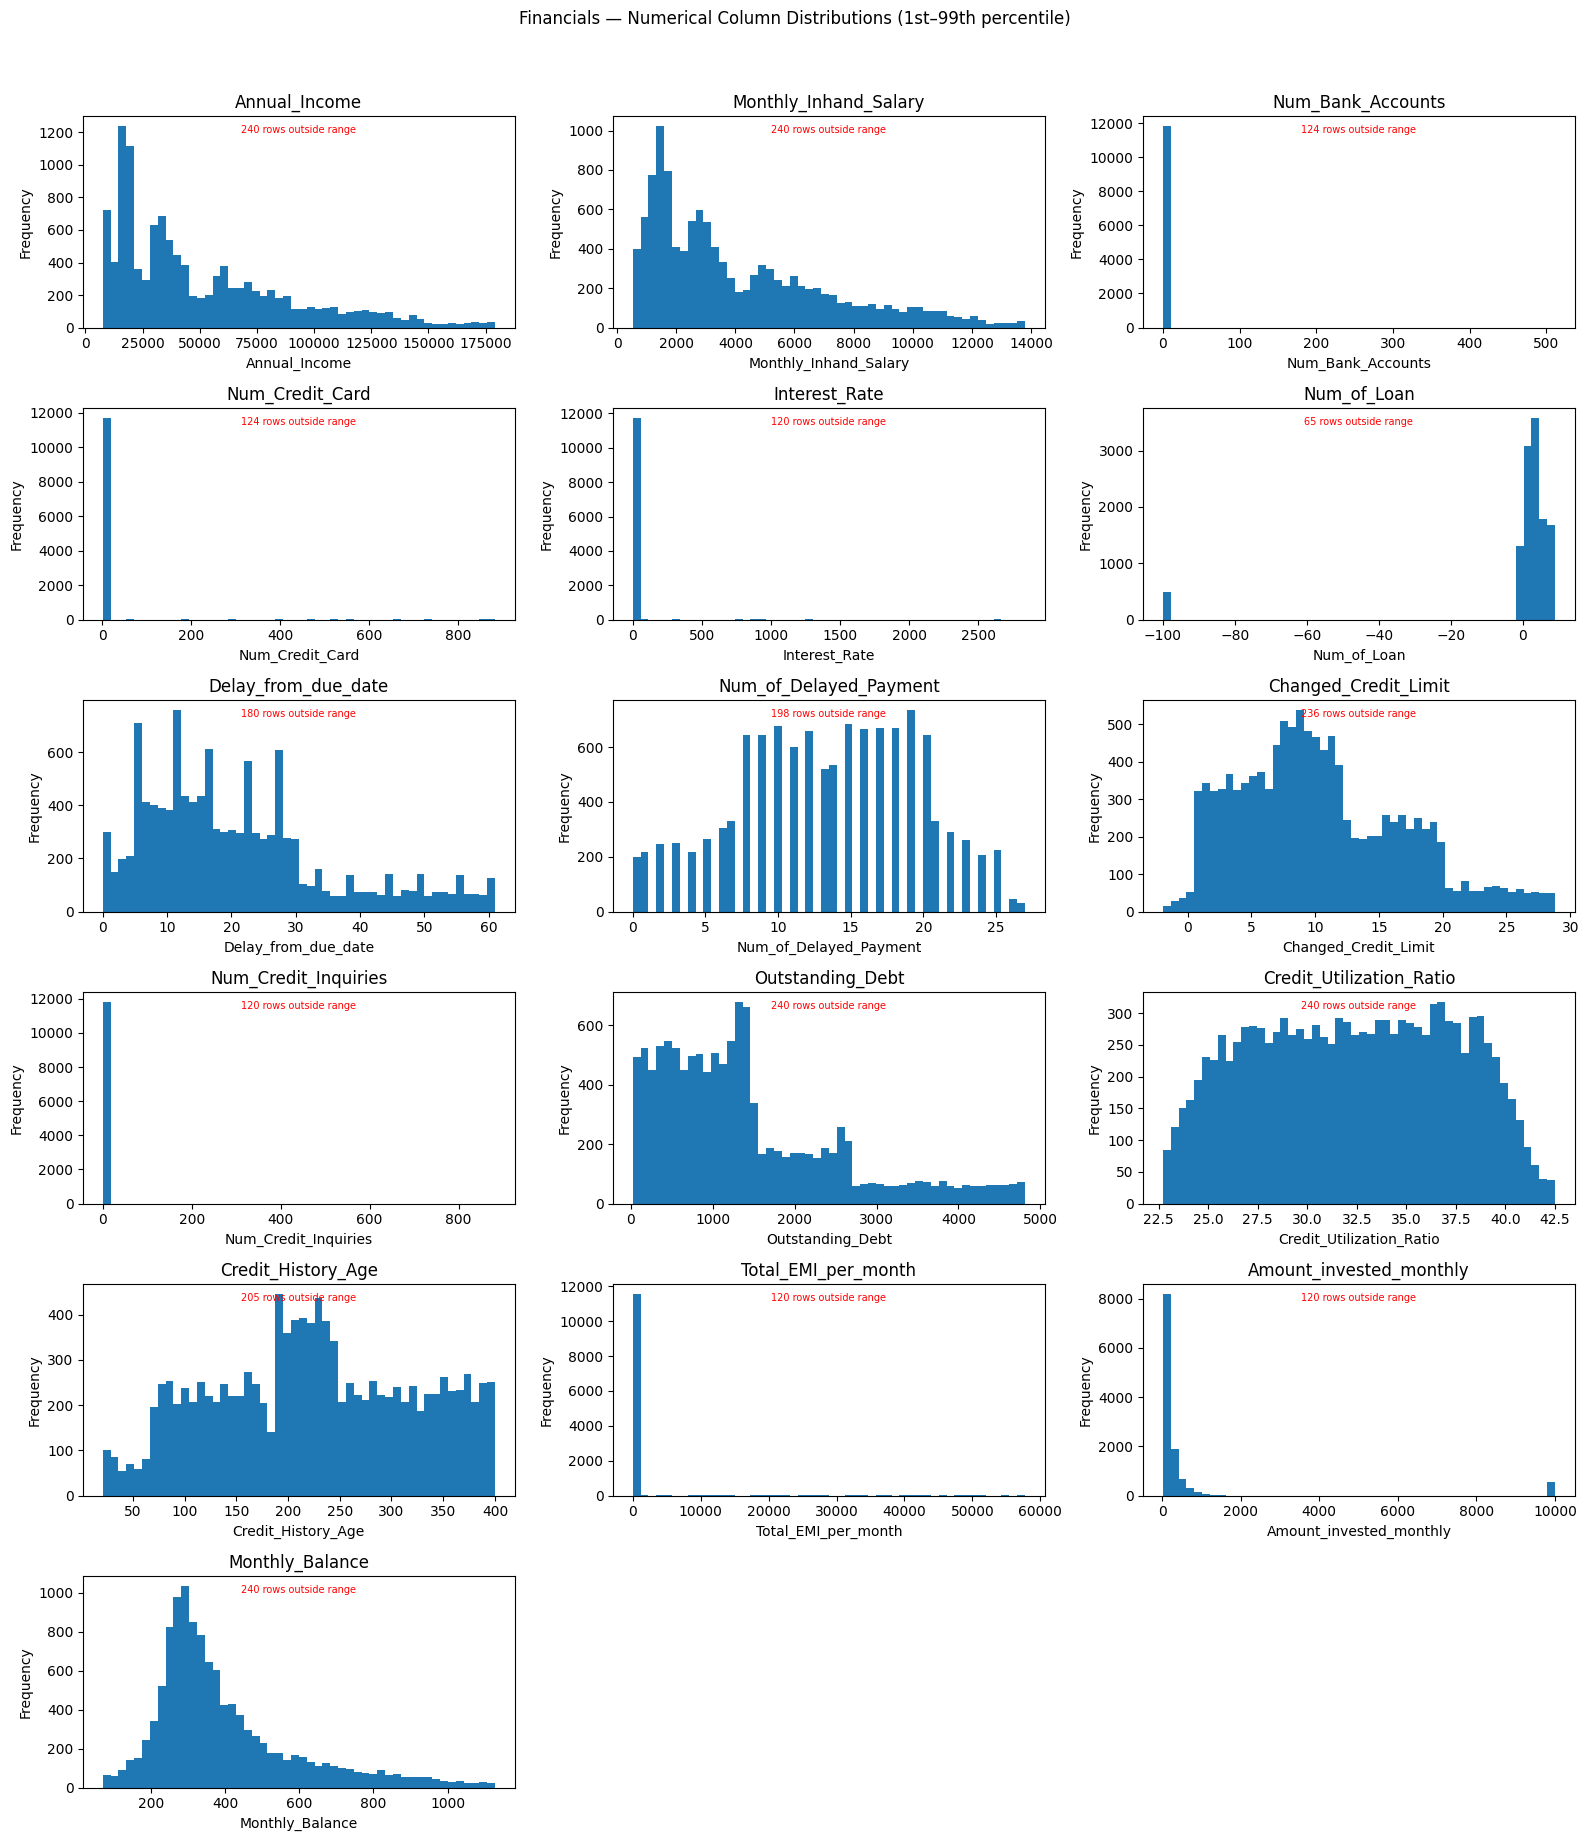

In [45]:
# Numerical columns
num_cols = pdf_fin.select_dtypes(include='number').columns.tolist()
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

# Plot histograms
n_cols = 3  # number of columns in the grid
n_rows = -(-len(num_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = pdf_fin[col].dropna()
    
    # Cap x-axis at 1st and 99th percentile to ignore extreme outliers
    p1  = data.quantile(0.01)
    p99 = data.quantile(0.99)
    
    axes[i].hist(data, bins=50, range=(p1, p99))
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

    # Annotate how many rows were outside the displayed range
    n_outside = ((data < p1) | (data > p99)).sum()
    if n_outside > 0:
        axes[i].annotate(f'{n_outside} rows outside range', 
                         xy=(0.5, 0.92), xycoords='axes fraction',
                         ha='center', fontsize=7, color='red')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Financials — Numerical Column Distributions (1st–99th percentile)', y=1.02)
plt.tight_layout()
plt.show()

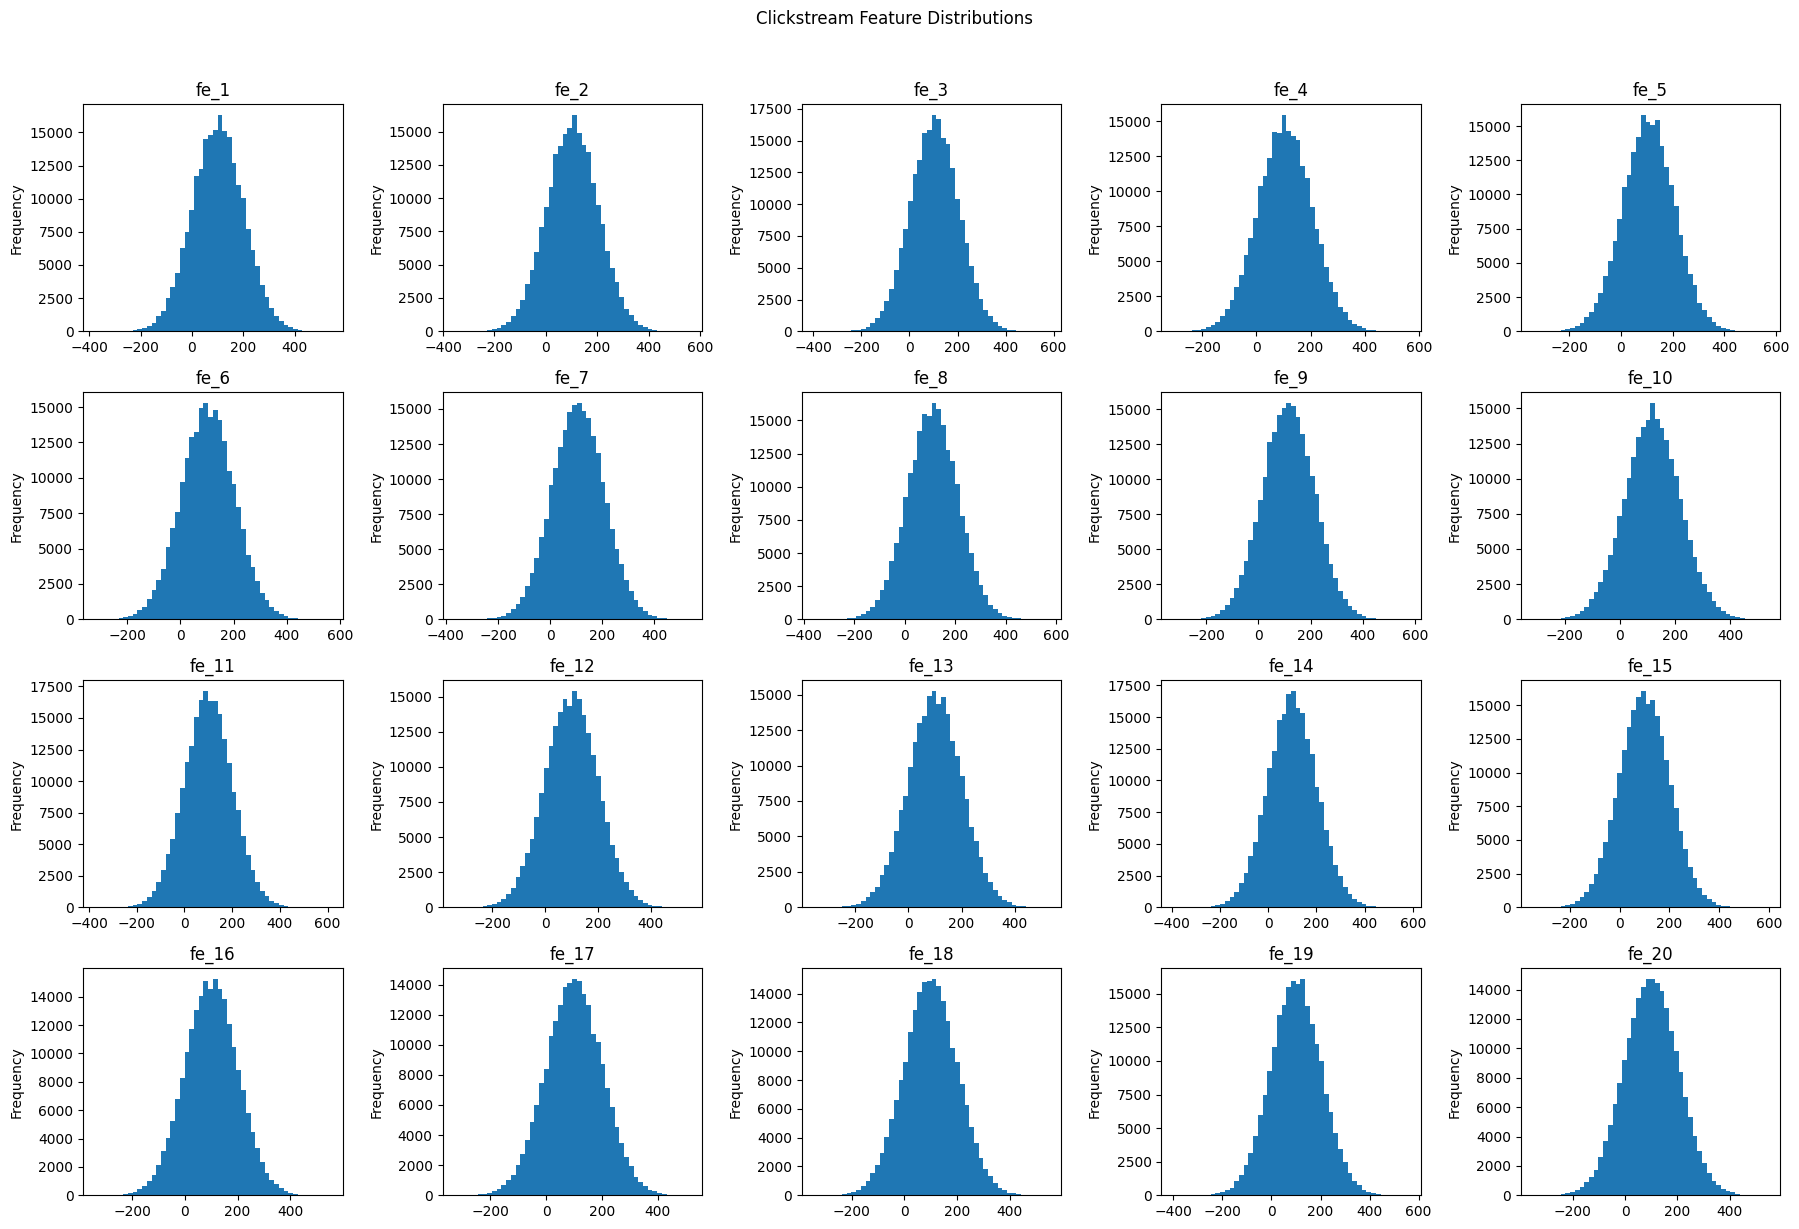

In [46]:
# Clickstream columns
fe_cols = [f"fe_{i}" for i in range(1, 21)]

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(fe_cols):
    pdf_click[col].dropna().plot(kind='hist', bins=50, ax=axes[i], title=col)

plt.suptitle('Clickstream Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

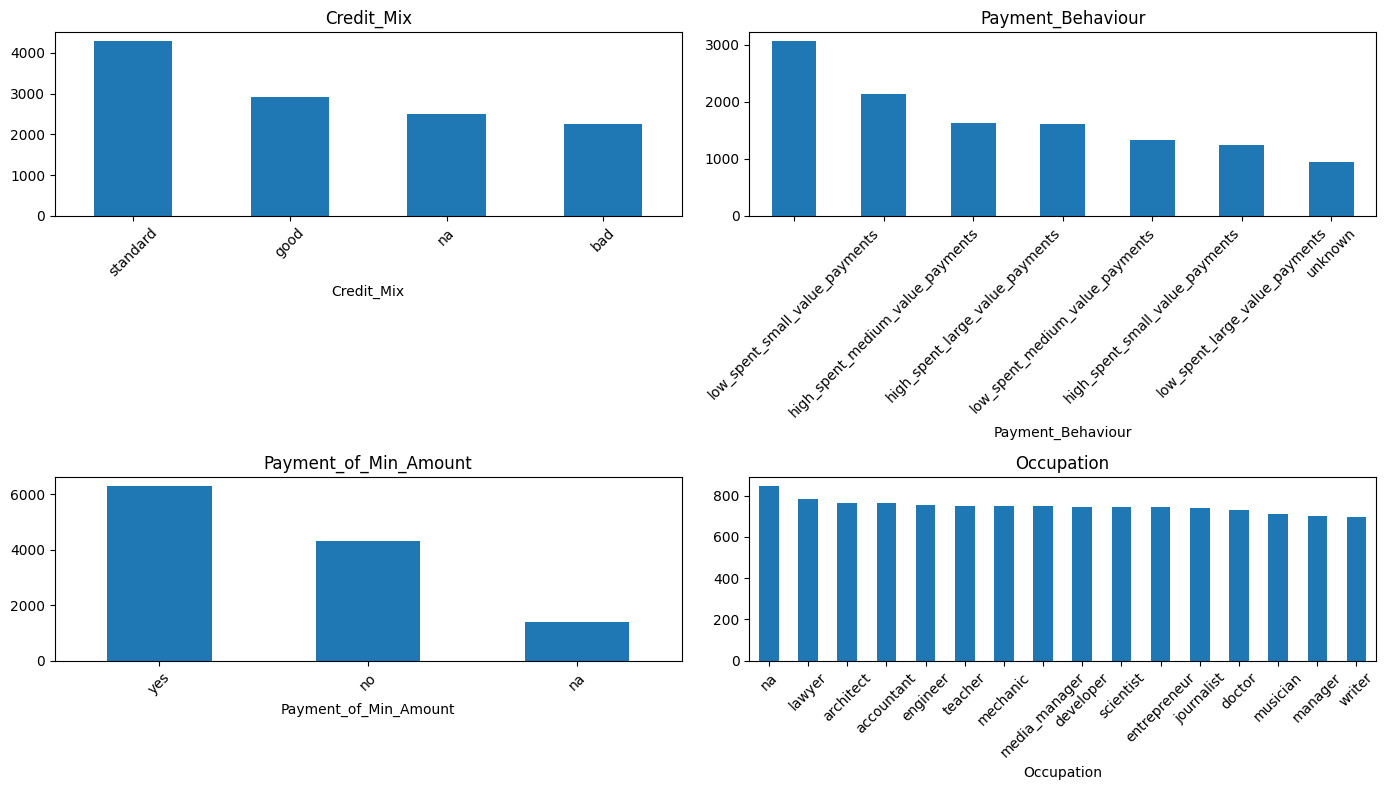

In [47]:
# Categorical columns
cat_cols = ['Credit_Mix', 'Payment_Behaviour', 'Payment_of_Min_Amount', 'Occupation']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    pdf = pdf_fin if col != 'Occupation' else pdf_attr
    pdf[col].value_counts().plot(kind='bar', ax=axes[i], title=col)
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

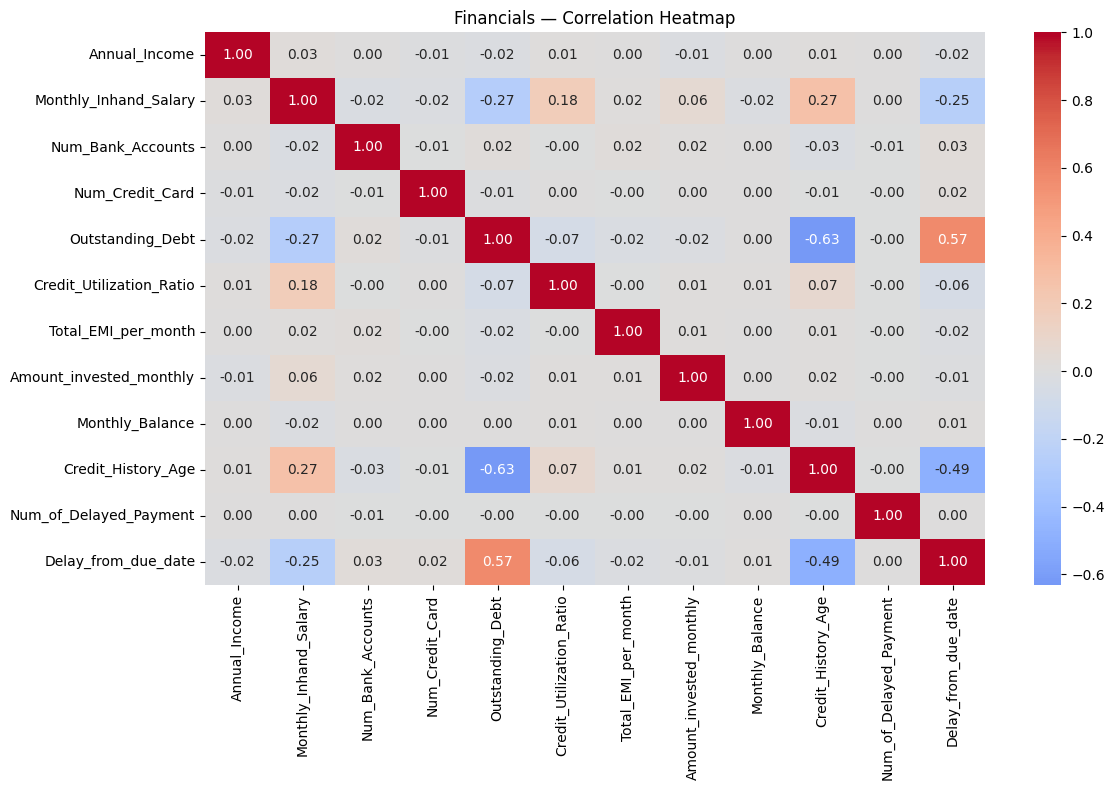

In [48]:
num_cols_corr = ['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
                 'Num_Credit_Card', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
                 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
                 'Credit_History_Age', 'Num_of_Delayed_Payment', 'Delay_from_due_date']

corr = pdf_fin[num_cols_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Financials — Correlation Heatmap')
plt.tight_layout()
plt.show()

## Build Gold Table

In [49]:
# create gold datalake
gold_features_directory = "datamart/gold/features/baseline"
gold_features_directory_full = "datamart/gold/features/full"

if not os.path.exists(gold_features_directory):
    os.makedirs(gold_features_directory)

if not os.path.exists(gold_features_directory_full):
    os.makedirs(gold_features_directory_full)

In [50]:
from utils import data_processing_gold_table_features
# run gold backfill
for date_str in dates_str_lst:
    utils.data_processing_gold_table_features.process_gold_features_table(date_str, silver_features_directory, gold_features_directory, gold_features_directory_full, spark)


[2023-01-01] loaded | financials: 530 | attributes: 530 | clickstream: 8974

[2023-01-01] --- Building Gold Table 1: Baseline ---
[2023-01-01] fixing negative values...
[2023-01-01] clamping outliers...
  clamped Annual_Income: [7296.72, 172085.28]
  clamped Monthly_Inhand_Salary: [515.86, 12869.03]
  clamped Num_Bank_Accounts: [0.00, 10.00]
  clamped Num_Credit_Card: [1.00, 426.00]
  clamped Interest_Rate: [1.00, 2915.00]
  clamped Num_of_Loan: [0.00, 9.00]
  clamped Delay_from_due_date: [0.00, 60.00]
  clamped Num_of_Delayed_Payment: [0.00, 27.00]
  clamped Num_Credit_Inquiries: [0.00, 777.00]
  clamped Outstanding_Debt: [25.78, 4806.96]
  clamped Total_EMI_per_month: [0.00, 57567.00]
  clamped Amount_invested_monthly: [17.25, 10000.00]
  clamped Monthly_Balance: [91.99, 1102.42]
  clamped Changed_Credit_Limit: [-3.12, 27.15]
  clamped Credit_History_Age: [18.00, 400.00]
[2023-01-01] encoding categorical columns...
[2023-01-01] engineering features...
[2023-01-01] Gold Table 1 saved:

In [52]:
df_baseline, df_full = utils.data_processing_gold_table_features.process_gold_features_table(date_str, silver_features_directory, gold_features_directory, gold_features_directory_full, spark)


[2024-12-01] loaded | financials: 515 | attributes: 515 | clickstream: 8974

[2024-12-01] --- Building Gold Table 1: Baseline ---
[2024-12-01] fixing negative values...
[2024-12-01] clamping outliers...
  clamped Annual_Income: [8128.06, 175572.44]
  clamped Monthly_Inhand_Salary: [633.80, 13672.44]
  clamped Num_Bank_Accounts: [0.00, 26.00]
  clamped Num_Credit_Card: [1.00, 446.00]
  clamped Interest_Rate: [1.00, 990.00]
  clamped Num_of_Loan: [0.00, 653.00]
  clamped Delay_from_due_date: [0.00, 60.00]
  clamped Num_of_Delayed_Payment: [0.00, 27.00]
  clamped Num_Credit_Inquiries: [0.00, 193.00]
  clamped Outstanding_Debt: [16.30, 4439.31]
  clamped Total_EMI_per_month: [0.00, 49236.00]
  clamped Amount_invested_monthly: [17.89, 10000.00]
  clamped Monthly_Balance: [66.62, 1078.80]
  clamped Changed_Credit_Limit: [-2.43, 26.98]
  clamped Credit_History_Age: [32.00, 398.00]
[2024-12-01] encoding categorical columns...
[2024-12-01] engineering features...
[2024-12-01] Gold Table 1 saved

In [53]:
df_baseline.dtypes

[('Customer_ID', 'string'),
 ('Annual_Income', 'double'),
 ('Monthly_Inhand_Salary', 'double'),
 ('Num_Bank_Accounts', 'double'),
 ('Num_Credit_Card', 'double'),
 ('Interest_Rate', 'double'),
 ('Num_of_Loan', 'double'),
 ('Delay_from_due_date', 'double'),
 ('Num_of_Delayed_Payment', 'double'),
 ('Changed_Credit_Limit', 'double'),
 ('Num_Credit_Inquiries', 'double'),
 ('Outstanding_Debt', 'double'),
 ('Credit_Utilization_Ratio', 'float'),
 ('Credit_History_Age', 'double'),
 ('Total_EMI_per_month', 'double'),
 ('Amount_invested_monthly', 'double'),
 ('Monthly_Balance', 'double'),
 ('Age', 'int'),
 ('Credit_Mix_encoded', 'int'),
 ('Payment_of_Min_Amount_encoded', 'int'),
 ('pb_spent_level', 'int'),
 ('pb_payment_size', 'int'),
 ('Occupation_encoded', 'int'),
 ('debt_to_income', 'double'),
 ('emi_to_salary', 'double'),
 ('savings_rate', 'double'),
 ('payment_stress', 'double'),
 ('loans_per_credit_card', 'double'),
 ('monthly_surplus', 'double'),
 ('snapshot_date', 'string')]

## inspect label store

In [56]:
folder_path = gold_features_directory
files_list = [os.path.join(folder_path, os.path.basename(f)) for f in glob.glob(os.path.join(folder_path, '*'))]
df_baseline = spark.read.option("header", "true").parquet(*files_list)
print("row_count:", df_baseline.count())

df_baseline.show()

row_count: 11974
+-----------+----------------+---------------------+-----------------+---------------+-------------+-----------+-------------------+----------------------+--------------------+--------------------+------------------+------------------------+------------------+-------------------+-----------------------+------------------+----+------------------+-----------------------------+--------------+---------------+------------------+--------------+-------------+------------+--------------+---------------------+---------------+-------------+
|Customer_ID|   Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|  Outstanding_Debt|Credit_Utilization_Ratio|Credit_History_Age|Total_EMI_per_month|Amount_invested_monthly|   Monthly_Balance| Age|Credit_Mix_encoded|Payment_of_Min_Amount_encoded|pb_spent_level|pb_payment_size|Occupation_encoded|debt_to_income|emi_

In [57]:
folder_path = gold_features_directory_full
files_list = [os.path.join(folder_path, os.path.basename(f)) for f in glob.glob(os.path.join(folder_path, '*'))]
df_full = spark.read.option("header", "true").parquet(*files_list)
print("full row_count:", df_full.count())
df_full.show()

full row_count: 8974
+-----------+----------------+---------------------+-----------------+---------------+-------------+-----------+-------------------+----------------------+--------------------+--------------------+------------------+------------------------+------------------+-------------------+-----------------------+------------------+---+------+------+-----+-----+-----+------+------+-----+------+------+-----+------+-----+-----+------+------+------+-----+------+-----+------------------+-----------------------------+--------------+---------------+------------------+--------------+-------------+------------+--------------+---------------------+---------------+-------------+
|Customer_ID|   Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|  Outstanding_Debt|Credit_Utilization_Ratio|Credit_History_Age|Total_EMI_per_month|Amount_invested_monthly|   Month